In [1]:
# =========================================================
# Notebook 2: Model Training and Test Evaluation
# Purpose:
# This notebook trains the deepfake detection model using
# processed video frame sequences. It handles:
# - loading dataset splits
# - building dataloaders
# - defining the CNN + LSTM model
# - training with checkpoint support
# - selecting the best model using validation macro F1
# - evaluating final performance on the test set
# =========================================================

In [2]:
# This cell imports the main libraries used in the notebook
# for:
# - file handling and checkpoint saving
# - numerical processing with NumPy and pandas
# - image loading and transformations
# - PyTorch model building and training
# - dataset preparation and DataLoader creation
# - evaluation metrics such as accuracy and F1-score
import os
import cv2
import re
import gc
import json
import glob
import time
import random
from typing import Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNeXt50_32X4D_Weights

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True
torch.backends.cudnn.deterministic = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
# This cell:
# - defines the folder containing the train/validation/test CSV files
# - defines the checkpoint directory for saving model progress
# - creates the checkpoint folder if it does not exist
# - loads train_df, val_df, and test_df from the split CSV files
SPLIT_DIR = r"D:\Courses\DEPI\project\DeepFake\splits_v6"
CHECKPOINT_DIR = r"D:\Courses\DEPI\project\DeepFake\checkpoints_v6"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

train_df = pd.read_csv(os.path.join(SPLIT_DIR, "train_df.csv"))
val_df = pd.read_csv(os.path.join(SPLIT_DIR, "val_df.csv"))
test_df = pd.read_csv(os.path.join(SPLIT_DIR, "test_df.csv"))

print("Train size:", len(train_df))
print(train_df["label"].value_counts(), "\n")
print("Val size:", len(val_df))
print(val_df["label"].value_counts(), "\n")
print("Test size:", len(test_df))
print(test_df["label"].value_counts())

Train size: 2429
label
0    1321
1    1108
Name: count, dtype: int64 

Val size: 521
label
0    283
1    238
Name: count, dtype: int64 

Test size: 521
label
0    284
1    237
Name: count, dtype: int64


In [4]:
# This cell sets the main training parameters such as:
# - image size
# - sequence length (number of frames per sample)
# - batch size
# - number of workers
# - learning rate
# - total number of epochs
#
# V8 stability update:
# - use the SAME augmentation policy for real and fake to avoid class-specific augmentation bias
# - default to CrossEntropy + light label smoothing (more stable than focal here)
# - keep validation threshold sweep, but penalize a large fake/real F1 gap when selecting best model
# - use smoother face crop by reusing the last detected box inside a sequence
IMAGE_SIZE = 224
SEQUENCE_LENGTH = 32
BATCH_SIZE = 2

# Keep this 0 while debugging / checkpoint resume.
NUM_WORKERS = 0

NUM_EPOCHS = 20
EARLY_STOPPING_PATIENCE = 4

LEARNING_RATE = 3e-5
WEIGHT_DECAY = 1e-4
HIDDEN_DIM = 256
LSTM_LAYERS = 1
DROPOUT = 0.4

USE_MIXED_PRECISION = torch.cuda.is_available()
SAVE_EVERY_N_BATCHES = 100
RESUME_TRAINING = True

# IMPORTANT:
# Keep only ONE imbalance-handling strategy at a time.
# In this dataset, fake source bias is already strong, so we avoid aggressive re-weighting by default.
USE_WEIGHTED_SAMPLER = False
USE_CLASS_WEIGHTS = False
USE_FOCAL_LOSS = False
FOCAL_GAMMA = 2.0
LABEL_SMOOTHING = 0.02

VAL_THRESHOLD_SWEEP = True
VAL_THRESHOLD_GRID = np.round(np.arange(0.30, 0.71, 0.01), 2)

# Best-model selection:
# We still reward tuned validation macro F1, but subtract a small penalty
# when fake/real F1 are far apart. This reduces the chance of saving a model
# that looks good overall but is weak on Real.
SELECT_BEST_BY = "macro_f1_tuned_gap_penalized"   # options: macro_f1, macro_f1_tuned, macro_f1_tuned_gap_penalized
F1_GAP_PENALTY = 0.15

# ---------------- Face-centric training ----------------
USE_FACE_CROP = True
FACE_EXPAND_RATIO = 0.25
FACE_DETECT_EVERY_N_FRAMES = 2
FALLBACK_TO_FULL_FRAME_IF_NO_FACE = True

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

class AddGaussianNoise(object):
    def __init__(self, std=0.02, p=0.20):
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() > self.p:
            return tensor
        noise = torch.randn_like(tensor) * self.std
        return torch.clamp(tensor + noise, 0.0, 1.0)

class RandomJPEGCompression(object):
    def __init__(self, quality_range=(45, 88), p=0.15):
        self.quality_range = quality_range
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        import io
        buffer = io.BytesIO()
        quality = random.randint(*self.quality_range)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        compressed = Image.open(buffer).convert("RGB")
        return compressed

# SAME augmentation policy for both classes to avoid introducing extra class bias.
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.08, hue=0.015),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.20),
    RandomJPEGCompression(quality_range=(45, 88), p=0.15),
    transforms.ToTensor(),
    AddGaussianNoise(std=0.02, p=0.20),
    transforms.Normalize(mean, std)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

print("USE_MIXED_PRECISION   :", USE_MIXED_PRECISION)
print("USE_FACE_CROP         :", USE_FACE_CROP)
print("FACE_DETECT_EVERY_N   :", FACE_DETECT_EVERY_N_FRAMES)
print("USE_WEIGHTED_SAMPLER  :", USE_WEIGHTED_SAMPLER)
print("USE_CLASS_WEIGHTS     :", USE_CLASS_WEIGHTS)
print("USE_FOCAL_LOSS        :", USE_FOCAL_LOSS)
print("LABEL_SMOOTHING       :", LABEL_SMOOTHING)
print("FACE_EXPAND_RATIO     :", FACE_EXPAND_RATIO)
print("SELECT_BEST_BY        :", SELECT_BEST_BY)

USE_MIXED_PRECISION   : True
USE_FACE_CROP         : True
FACE_DETECT_EVERY_N   : 2
USE_WEIGHTED_SAMPLER  : False
USE_CLASS_WEIGHTS     : False
USE_FOCAL_LOSS        : False
LABEL_SMOOTHING       : 0.02
FACE_EXPAND_RATIO     : 0.25
SELECT_BEST_BY        : macro_f1_tuned_gap_penalized


In [5]:
# This cell contains:
# - a helper function to read frame paths from a folder
# - a lightweight OpenCV face detector wrapper
# - the custom FrameFolderDataset class with OPTIONAL online face crop
#
# V8 update:
# - smoother face crop by reusing the last valid face box within a sequence
# - configurable detection frequency to reduce noise and speed up training
# - same transform policy for both classes (no class-specific augmentation bias)
def natural_key(text):
    return [int(tok) if tok.isdigit() else tok.lower() for tok in re.split(r"(\d+)", str(text))]

def get_frame_paths(folder_path: str):
    valid_exts = {".jpg", ".jpeg", ".png"}
    frame_paths = []
    for name in os.listdir(folder_path):
        full_path = os.path.join(folder_path, name)
        if os.path.isfile(full_path):
            ext = os.path.splitext(name)[1].lower()
            if ext in valid_exts:
                frame_paths.append(full_path)
    return sorted(frame_paths, key=natural_key)

class FastFaceDetector:
    """Simple Haar-based detector for online face crop."""
    def __init__(self):
        haar_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
        self.detector = cv2.CascadeClassifier(haar_path)
        if self.detector.empty():
            raise ValueError(f"Could not load Haar cascade from: {haar_path}")

    def detect_largest_face(self, frame_bgr):
        gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
        faces = self.detector.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )
        if len(faces) == 0:
            return None
        faces = sorted(faces, key=lambda b: b[2] * b[3], reverse=True)
        x, y, w, h = faces[0]
        return (int(x), int(y), int(w), int(h))

FACE_DETECTOR = FastFaceDetector() if USE_FACE_CROP else None

def crop_from_box(frame_bgr, box, expand_ratio=0.25):
    if box is None:
        return None

    h, w = frame_bgr.shape[:2]
    x, y, bw, bh = box
    cx = x + bw / 2.0
    cy = y + bh / 2.0

    bw *= (1.0 + expand_ratio)
    bh *= (1.0 + expand_ratio)

    x1 = max(0, int(cx - bw / 2.0))
    y1 = max(0, int(cy - bh / 2.0))
    x2 = min(w, int(cx + bw / 2.0))
    y2 = min(h, int(cy + bh / 2.0))

    if x2 <= x1 or y2 <= y1:
        return None

    cropped = frame_bgr[y1:y2, x1:x2]
    if cropped.size == 0:
        return None
    cropped = cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB)
    return Image.fromarray(cropped)

class FrameFolderDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        sequence_length: int = 32,
        transform=None,
        sampling_mode: str = "uniform",
        base_seed: int = 42,
        use_face_crop: bool = False,
        face_expand_ratio: float = 0.25,
        face_detect_every_n_frames: int = 1,
        fallback_full_frame_if_no_face: bool = True,
    ):
        self.df = df.reset_index(drop=True)
        self.sequence_length = sequence_length
        self.transform = transform
        self.sampling_mode = sampling_mode
        self.base_seed = base_seed
        self.current_epoch = 0
        self.use_face_crop = use_face_crop
        self.face_expand_ratio = face_expand_ratio
        self.face_detect_every_n_frames = max(1, int(face_detect_every_n_frames))
        self.fallback_full_frame_if_no_face = fallback_full_frame_if_no_face

        self.folder_to_frames = {}
        for _, row in self.df.iterrows():
            folder_path = row["folder_path"]
            if folder_path not in self.folder_to_frames:
                self.folder_to_frames[folder_path] = get_frame_paths(folder_path)

    def set_epoch(self, epoch: int):
        self.current_epoch = epoch

    def __len__(self):
        return len(self.df)

    def _select_paths(self, frame_paths, idx):
        n = len(frame_paths)
        if n == 0:
            raise ValueError(f"No frames found in folder: {self.df.iloc[idx]['folder_path']}")

        if n < self.sequence_length:
            selected_paths = list(frame_paths)
            while len(selected_paths) < self.sequence_length:
                selected_paths.append(selected_paths[-1])
            return selected_paths

        if self.sampling_mode == "uniform":
            indices = np.linspace(0, n - 1, self.sequence_length, dtype=int)
            return [frame_paths[i] for i in indices]

        rng = np.random.default_rng(self.base_seed + self.current_epoch * 100000 + idx)
        bin_edges = np.linspace(0, n, self.sequence_length + 1, dtype=int)

        indices = []
        for i in range(self.sequence_length):
            start = int(bin_edges[i])
            end = int(bin_edges[i + 1])
            if end <= start:
                pick = min(start, n - 1)
            else:
                pick = int(rng.integers(start, end))
            indices.append(min(pick, n - 1))

        indices = np.sort(np.array(indices))
        return [frame_paths[i] for i in indices]

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        folder_path = row["folder_path"]
        label = int(row["label"])

        frame_paths = self.folder_to_frames[folder_path]
        selected_paths = self._select_paths(frame_paths, idx)

        frames = []
        last_box = None

        for frame_i, fp in enumerate(selected_paths):
            with Image.open(fp) as img:
                img = img.convert("RGB")

                if self.use_face_crop:
                    frame_bgr = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)

                    should_redetect = (frame_i % self.face_detect_every_n_frames == 0) or (last_box is None)
                    if should_redetect:
                        detected_box = FACE_DETECTOR.detect_largest_face(frame_bgr) if FACE_DETECTOR is not None else None
                        if detected_box is not None:
                            last_box = detected_box

                    cropped = crop_from_box(frame_bgr, last_box, expand_ratio=self.face_expand_ratio)
                    if cropped is not None:
                        img = cropped
                    elif not self.fallback_full_frame_if_no_face:
                        raise ValueError(f"No usable face crop for frame: {fp}")

                img = self.transform(img) if self.transform else transforms.ToTensor()(img)
                frames.append(img)

        frames = torch.stack(frames)
        return frames, torch.tensor(label, dtype=torch.long), folder_path

In [6]:
# This cell defines the function that builds:
# - train dataset and train loader
# - validation dataset and validation loader
# - test dataset and test loader
#
# V8 update:
# - same transform policy for both classes
# - smoother online face crop with configurable detection frequency
# - weighted sampler remains optional, but disabled by default
def make_dataloaders(train_epoch: int = 0):
    train_dataset = FrameFolderDataset(
        train_df,
        sequence_length=SEQUENCE_LENGTH,
        transform=train_transforms,
        sampling_mode="random",
        base_seed=SEED,
        use_face_crop=USE_FACE_CROP,
        face_expand_ratio=FACE_EXPAND_RATIO,
        face_detect_every_n_frames=FACE_DETECT_EVERY_N_FRAMES,
        fallback_full_frame_if_no_face=FALLBACK_TO_FULL_FRAME_IF_NO_FACE
    )
    train_dataset.set_epoch(train_epoch)

    val_dataset = FrameFolderDataset(
        val_df,
        sequence_length=SEQUENCE_LENGTH,
        transform=val_transforms,
        sampling_mode="uniform",
        base_seed=SEED,
        use_face_crop=USE_FACE_CROP,
        face_expand_ratio=FACE_EXPAND_RATIO,
        face_detect_every_n_frames=FACE_DETECT_EVERY_N_FRAMES,
        fallback_full_frame_if_no_face=FALLBACK_TO_FULL_FRAME_IF_NO_FACE
    )

    test_dataset = FrameFolderDataset(
        test_df,
        sequence_length=SEQUENCE_LENGTH,
        transform=val_transforms,
        sampling_mode="uniform",
        base_seed=SEED,
        use_face_crop=USE_FACE_CROP,
        face_expand_ratio=FACE_EXPAND_RATIO,
        face_detect_every_n_frames=FACE_DETECT_EVERY_N_FRAMES,
        fallback_full_frame_if_no_face=FALLBACK_TO_FULL_FRAME_IF_NO_FACE
    )

    train_generator = torch.Generator()
    train_generator.manual_seed(SEED + train_epoch)

    sampler = None
    shuffle = True

    if USE_WEIGHTED_SAMPLER:
        label_counts = train_df["label"].value_counts().to_dict()
        sample_weights = train_df["label"].map(lambda y: 1.0 / label_counts[int(y)]).values
        sample_weights = torch.DoubleTensor(sample_weights)

        sampler = torch.utils.data.WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
            generator=train_generator
        )
        shuffle = False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        sampler=sampler,
        generator=None if sampler is not None else train_generator,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = make_dataloaders(train_epoch=0)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader))

frames, labels, folder_paths = next(iter(train_loader))
print("Frames shape:", frames.shape)
print("Labels      :", labels.tolist())
print("Example path:", folder_paths[0])

Train batches: 1215
Val batches  : 261
Test batches : 261
Frames shape: torch.Size([2, 32, 3, 224, 224])
Labels      : [1, 0]
Example path: D:\Courses\DEPI\project\DeepFake\processed\Real\new_real\id9_0000


In [7]:
# This cell defines the DeepFakeModel class.
#
# V7 update:
# - BiLSTM temporal encoder
# - ATTENTION pooling over time (better than simple mean pooling)
class TemporalAttentionPooling(nn.Module):
    def __init__(self, in_dim: int):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2),
            nn.Tanh(),
            nn.Linear(in_dim // 2, 1)
        )

    def forward(self, x):
        # x: [B, T, C]
        attn_logits = self.score(x).squeeze(-1)
        attn_weights = torch.softmax(attn_logits, dim=1)
        pooled = torch.sum(x * attn_weights.unsqueeze(-1), dim=1)
        return pooled, attn_weights

class DeepFakeModel(nn.Module):
    def __init__(self, num_classes=2, hidden_dim=256, lstm_layers=1, dropout=0.4, freeze_backbone=False):
        super().__init__()

        backbone = models.resnext50_32x4d(weights=ResNeXt50_32X4D_Weights.DEFAULT)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.feature_dim = 2048

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        self.lstm = nn.LSTM(
            input_size=self.feature_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.0 if lstm_layers == 1 else dropout
        )

        temporal_dim = hidden_dim * 2
        self.temporal_attention = TemporalAttentionPooling(temporal_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(temporal_dim, num_classes)

    def forward(self, x, return_attention=False):
        batch_size, seq_len, c, h, w = x.shape
        x = x.view(batch_size * seq_len, c, h, w)

        feats = self.backbone(x)
        feats = self.avgpool(feats).flatten(1)
        feats = feats.view(batch_size, seq_len, self.feature_dim)

        lstm_out, _ = self.lstm(feats)
        temporal_feat, attn_weights = self.temporal_attention(lstm_out)

        out = self.dropout(temporal_feat)
        out = self.fc(out)

        if return_attention:
            return out, attn_weights
        return out

model = DeepFakeModel(
    num_classes=2,
    hidden_dim=HIDDEN_DIM,
    lstm_layers=LSTM_LAYERS,
    dropout=DROPOUT,
    freeze_backbone=False
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")


Total params    : 27,835,203
Trainable params: 27,835,203


In [8]:
# This cell prepares all core training elements, including:
# - class weights to handle data imbalance (optional)
# - focal loss option for hard examples
# - optimizer / scheduler / scaler
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, reduction="none", weight=self.alpha)
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce

        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

class_weights = None
if USE_CLASS_WEIGHTS:
    class_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=np.array(sorted(train_df["label"].unique())),
        y=train_df["label"].values
    )
    class_weights = torch.tensor(class_weights_np, dtype=torch.float32, device=device)

if USE_FOCAL_LOSS:
    criterion = FocalLoss(alpha=class_weights, gamma=FOCAL_GAMMA)
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTHING)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_MIXED_PRECISION)

print("Criterion type:", criterion.__class__.__name__)
print("Class weights  :", None if class_weights is None else class_weights.detach().cpu().numpy())

Criterion type: CrossEntropyLoss
Class weights  : None


In [9]:
# This cell defines helper functions for:
# - saving training checkpoints
# - restoring training checkpoints
# - preserving optimizer, scheduler, scaler, and RNG state
# - resuming from the last saved epoch or batch
#
# It also defines file paths for:
# - the latest training checkpoint
# - the best saved model
# - the training history JSON file
checkpoint_path = os.path.join(CHECKPOINT_DIR, "training_checkpoint_v8.pth")
best_model_path = os.path.join(CHECKPOINT_DIR, "best_model_v8.pth")
history_path = os.path.join(CHECKPOINT_DIR, "training_history_v8.json")

def get_rng_state():
    state = {
        "python_random_state": random.getstate(),
        "numpy_random_state": np.random.get_state(),
        "torch_random_state": torch.get_rng_state(),
    }
    if torch.cuda.is_available():
        state["torch_cuda_random_state_all"] = torch.cuda.get_rng_state_all()
    return state

def set_rng_state(state_dict):
    if state_dict is None:
        return

    try:
        if "python_random_state" in state_dict:
            random.setstate(state_dict["python_random_state"])
    except Exception as e:
        print("Warning: python RNG state restore failed:", e)

    try:
        if "numpy_random_state" in state_dict:
            np.random.set_state(state_dict["numpy_random_state"])
    except Exception as e:
        print("Warning: numpy RNG state restore failed:", e)

    try:
        if "torch_random_state" in state_dict:
            torch_state = state_dict["torch_random_state"]
            if isinstance(torch_state, torch.Tensor):
                torch_state = torch_state.detach().cpu().clone()
            else:
                torch_state = torch.as_tensor(torch_state, dtype=torch.uint8)
            if torch_state.dtype != torch.uint8:
                torch_state = torch_state.to(torch.uint8)
            torch.set_rng_state(torch_state)
    except Exception as e:
        print("Warning: torch CPU RNG state restore failed:", e)

    try:
        if torch.cuda.is_available() and "torch_cuda_random_state_all" in state_dict:
            cuda_states = []
            for s in state_dict["torch_cuda_random_state_all"]:
                if isinstance(s, torch.Tensor):
                    s = s.detach().cpu().clone()
                else:
                    s = torch.as_tensor(s, dtype=torch.uint8)
                if s.dtype != torch.uint8:
                    s = s.to(torch.uint8)
                cuda_states.append(s)
            torch.cuda.set_rng_state_all(cuda_states)
    except Exception as e:
        print("Warning: torch CUDA RNG state restore failed:", e)

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    next_batch_idx,
    best_val_macro_f1,
    best_threshold,
    patience_counter,
    history,
    note=""
):
    ckpt = {
        "epoch": epoch,
        "next_batch_idx": next_batch_idx,
        "best_val_macro_f1": best_val_macro_f1,
        "best_threshold": best_threshold,
        "patience_counter": patience_counter,
        "history": history,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "rng_state": get_rng_state(),
        "note": note,
        "saved_at": time.strftime("%Y-%m-%d %H:%M:%S")
    }
    torch.save(ckpt, path)

def load_checkpoint(path, model, optimizer, scheduler, scaler, map_location=device):
    ckpt = torch.load(path, map_location=map_location, weights_only=False)

    model.load_state_dict(ckpt["model_state_dict"])
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    if scheduler is not None and ckpt.get("scheduler_state_dict") is not None:
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    if scaler is not None and ckpt.get("scaler_state_dict") is not None:
        scaler.load_state_dict(ckpt["scaler_state_dict"])

    if "rng_state" in ckpt:
        try:
            set_rng_state(ckpt["rng_state"])
        except Exception as e:
            print("Warning: RNG state was not restored:", e)

    start_epoch = ckpt.get("epoch", 0)
    resume_batch_idx = ckpt.get("next_batch_idx", 0)
    best_val_macro_f1 = ckpt.get("best_val_macro_f1", -1.0)
    best_threshold = ckpt.get("best_threshold", 0.50)
    patience_counter = ckpt.get("patience_counter", 0)
    history = ckpt.get("history", {"train": [], "val": []})

    return (
        start_epoch,
        resume_batch_idx,
        best_val_macro_f1,
        best_threshold,
        patience_counter,
        history,
        ckpt
    )

In [10]:
# This cell includes:
# - metric calculation functions
# - validation threshold sweep helpers
# - the run_one_epoch() function
def compute_epoch_metrics(labels, preds):
    labels = np.array(labels)
    preds = np.array(preds)

    acc = float((preds == labels).mean())

    fake_f1 = float(f1_score(labels, preds, pos_label=0, zero_division=0))
    real_f1 = float(f1_score(labels, preds, pos_label=1, zero_division=0))
    macro_f1 = float(f1_score(labels, preds, average="macro", zero_division=0))

    fake_precision = float(precision_score(labels, preds, pos_label=0, zero_division=0))
    fake_recall = float(recall_score(labels, preds, pos_label=0, zero_division=0))

    real_precision = float(precision_score(labels, preds, pos_label=1, zero_division=0))
    real_recall = float(recall_score(labels, preds, pos_label=1, zero_division=0))

    return {
        "accuracy": acc,
        "fake_f1": fake_f1,
        "real_f1": real_f1,
        "macro_f1": macro_f1,
        "fake_precision": fake_precision,
        "fake_recall": fake_recall,
        "real_precision": real_precision,
        "real_recall": real_recall,
        "f1_gap": float(abs(fake_f1 - real_f1))
    }

def preds_from_real_threshold(probs, real_threshold=0.50):
    probs = np.asarray(probs)
    real_probs = probs[:, 1]
    return (real_probs >= real_threshold).astype(np.int64)

def evaluate_threshold_grid(labels, probs, thresholds):
    best = None
    for thr in thresholds:
        preds = preds_from_real_threshold(probs, real_threshold=float(thr))
        metrics = compute_epoch_metrics(labels, preds)
        candidate = {
            "threshold": float(thr),
            **metrics
        }
        if best is None or candidate["macro_f1"] > best["macro_f1"]:
            best = candidate
    return best

def apply_threshold_metrics(labels, probs, threshold):
    preds = preds_from_real_threshold(probs, real_threshold=float(threshold))
    return {
        "threshold": float(threshold),
        **compute_epoch_metrics(labels, preds),
        "preds": preds.tolist()
    }

def run_one_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer=None,
    scaler=None,
    epoch_idx=0,
    start_batch_idx=0,
    save_every_n_batches=None,
    checkpoint_callback=None,
    forced_threshold=None
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    progress = tqdm(
        enumerate(loader),
        total=len(loader),
        desc=f"{'Train' if is_train else 'Eval '} Epoch {epoch_idx + 1}"
    )

    for batch_idx, (frames, labels, _) in progress:
        if batch_idx < start_batch_idx:
            continue

        frames = frames.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast("cuda", enabled=(USE_MIXED_PRECISION and torch.cuda.is_available())):
                outputs = model(frames)
                loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * frames.size(0)
        all_labels.extend(labels.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_probs.extend(probs.detach().cpu().numpy())

        metrics = compute_epoch_metrics(all_labels, all_preds)
        avg_loss_so_far = running_loss / len(all_labels)

        progress.set_postfix({
            "loss": f"{avg_loss_so_far:.4f}",
            "acc": f"{metrics['accuracy']:.4f}",
            "macro_f1": f"{metrics['macro_f1']:.4f}",
            "fake_f1": f"{metrics['fake_f1']:.4f}",
            "real_f1": f"{metrics['real_f1']:.4f}",
        })

        if is_train and checkpoint_callback is not None and save_every_n_batches is not None:
            if (batch_idx + 1) % save_every_n_batches == 0:
                checkpoint_callback(
                    next_batch_idx=batch_idx + 1,
                    note=f"mid-epoch checkpoint @ batch {batch_idx + 1}"
                )

    epoch_loss = running_loss / max(len(all_labels), 1)
    metrics = compute_epoch_metrics(all_labels, all_preds)

    results = {
        "loss": float(epoch_loss),
        "accuracy": metrics["accuracy"],
        "fake_f1": metrics["fake_f1"],
        "real_f1": metrics["real_f1"],
        "macro_f1": metrics["macro_f1"],
        "fake_precision": metrics["fake_precision"],
        "fake_recall": metrics["fake_recall"],
        "real_precision": metrics["real_precision"],
        "real_recall": metrics["real_recall"],
        "f1_gap": metrics["f1_gap"],
        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs
    }

    if (not is_train) and len(all_labels) > 0:
        if VAL_THRESHOLD_SWEEP:
            tuned = evaluate_threshold_grid(all_labels, all_probs, VAL_THRESHOLD_GRID)
            results["best_threshold"] = tuned["threshold"]
            results["macro_f1_tuned"] = tuned["macro_f1"]
            results["real_f1_tuned"] = tuned["real_f1"]
            results["fake_f1_tuned"] = tuned["fake_f1"]
            results["accuracy_tuned"] = tuned["accuracy"]
            results["f1_gap_tuned"] = tuned["f1_gap"]
            results["preds_tuned"] = preds_from_real_threshold(all_probs, tuned["threshold"]).tolist()

        if forced_threshold is not None:
            forced = apply_threshold_metrics(all_labels, all_probs, forced_threshold)
            results["forced_threshold"] = forced["threshold"]
            results["accuracy_forced"] = forced["accuracy"]
            results["macro_f1_forced"] = forced["macro_f1"]
            results["fake_f1_forced"] = forced["fake_f1"]
            results["real_f1_forced"] = forced["real_f1"]
            results["f1_gap_forced"] = forced["f1_gap"]
            results["preds_forced"] = forced["preds"]

    return results

In [11]:
# This cell:
# - initializes training counters and history containers
# - resets best score and patience counter
# - optionally loads a previous checkpoint if resume mode is enabled
#
# It determines whether training will:
# - start from scratch
# - or continue from the last saved checkpoint
start_epoch = 0
resume_batch_idx = 0
best_val_macro_f1 = -1.0
best_threshold = 0.50
patience_counter = 0

history = {
    "train": [],
    "val": []
}

if RESUME_TRAINING and os.path.exists(checkpoint_path):
    (
        start_epoch,
        resume_batch_idx,
        best_val_macro_f1,
        best_threshold,
        patience_counter,
        history,
        loaded_ckpt
    ) = load_checkpoint(checkpoint_path, model, optimizer, scheduler, scaler, map_location=device)

    print("Checkpoint loaded successfully.")
    print("Saved at              :", loaded_ckpt.get("saved_at"))
    print("Resume epoch          :", start_epoch)
    print("Resume next batch idx :", resume_batch_idx)
    print("Best selection score  :", best_val_macro_f1)
    print("Best threshold        :", best_threshold)
    print("Patience counter      :", patience_counter)
    print("Checkpoint note       :", loaded_ckpt.get("note"))
else:
    print("No checkpoint loaded. Training will start from scratch.")

Checkpoint loaded successfully.
Saved at              : 2026-04-09 14:50:04
Resume epoch          : 10
Resume next batch idx : 0
Best selection score  : 0.9624053960849461
Best threshold        : 0.3
Patience counter      : 2
Checkpoint note       : end of epoch checkpoint


In [12]:
import time

start = time.time()
frames, labels, folder_paths = next(iter(train_loader))
end = time.time()

print("Loaded first batch in:", round(end - start, 2), "seconds")
print("Frames shape:", frames.shape)
print("Labels:", labels.tolist())
print("Example path:", folder_paths[0])

Loaded first batch in: 0.95 seconds
Frames shape: torch.Size([2, 32, 3, 224, 224])
Labels: [0, 1]
Example path: D:\Courses\DEPI\project\DeepFake\processed\Fake\new_fake\03_21__secret_conversation__YCSEBZO4


In [13]:
# This cell runs the full training process across epochs.
#
# For each epoch, it:
# - creates dataloaders
# - trains the model on the training set
# - evaluates on the validation set
# - updates the learning rate scheduler
# - saves the best model when validation improves
# - saves checkpoints and training history
# - applies early stopping when needed
for epoch in range(start_epoch, NUM_EPOCHS):
    print("\n" + "=" * 70)
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 70)

    train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = make_dataloaders(train_epoch=epoch)

    def mini_checkpoint_callback(next_batch_idx, note=""):
        save_checkpoint(
            path=checkpoint_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            epoch=epoch,
            next_batch_idx=next_batch_idx,
            best_val_macro_f1=best_val_macro_f1,
            best_threshold=best_threshold,
            patience_counter=patience_counter,
            history=history,
            note=note
        )

    train_results = run_one_epoch(
        model=model,
        loader=train_loader,
        criterion=criterion,
        device=device,
        optimizer=optimizer,
        scaler=scaler,
        epoch_idx=epoch,
        start_batch_idx=resume_batch_idx if epoch == start_epoch else 0,
        save_every_n_batches=SAVE_EVERY_N_BATCHES,
        checkpoint_callback=mini_checkpoint_callback
    )

    resume_batch_idx = 0

    val_results = run_one_epoch(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        optimizer=None,
        scaler=None,
        epoch_idx=epoch
    )

    # Scheduler should follow the same objective we care about.
    if "macro_f1_tuned" in val_results:
        scheduler_metric = val_results["macro_f1_tuned"] - (F1_GAP_PENALTY * val_results["f1_gap_tuned"])
    else:
        scheduler_metric = val_results["macro_f1"] - (F1_GAP_PENALTY * val_results["f1_gap"])
    scheduler.step(scheduler_metric)

    history["train"].append({
        "epoch": epoch + 1,
        "loss": train_results["loss"],
        "accuracy": train_results["accuracy"],
        "fake_f1": train_results["fake_f1"],
        "real_f1": train_results["real_f1"],
        "macro_f1": train_results["macro_f1"],
        "f1_gap": train_results["f1_gap"],
        "fake_precision": train_results["fake_precision"],
        "fake_recall": train_results["fake_recall"],
        "real_precision": train_results["real_precision"],
        "real_recall": train_results["real_recall"]
    })

    val_hist_entry = {
        "epoch": epoch + 1,
        "loss": val_results["loss"],
        "accuracy": val_results["accuracy"],
        "fake_f1": val_results["fake_f1"],
        "real_f1": val_results["real_f1"],
        "macro_f1": val_results["macro_f1"],
        "f1_gap": val_results["f1_gap"],
        "fake_precision": val_results["fake_precision"],
        "fake_recall": val_results["fake_recall"],
        "real_precision": val_results["real_precision"],
        "real_recall": val_results["real_recall"]
    }
    if "macro_f1_tuned" in val_results:
        val_hist_entry.update({
            "best_threshold": val_results["best_threshold"],
            "accuracy_tuned": val_results["accuracy_tuned"],
            "fake_f1_tuned": val_results["fake_f1_tuned"],
            "real_f1_tuned": val_results["real_f1_tuned"],
            "macro_f1_tuned": val_results["macro_f1_tuned"],
            "f1_gap_tuned": val_results["f1_gap_tuned"],
        })

    history["val"].append(val_hist_entry)

    print(
        f"Train | loss={train_results['loss']:.4f} | acc={train_results['accuracy']:.4f} | "
        f"macro_f1={train_results['macro_f1']:.4f} | fake_f1={train_results['fake_f1']:.4f} | "
        f"real_f1={train_results['real_f1']:.4f} | gap={train_results['f1_gap']:.4f}"
    )
    print(
        f"Val   | loss={val_results['loss']:.4f} | acc={val_results['accuracy']:.4f} | "
        f"macro_f1={val_results['macro_f1']:.4f} | fake_f1={val_results['fake_f1']:.4f} | "
        f"real_f1={val_results['real_f1']:.4f} | gap={val_results['f1_gap']:.4f}"
    )

    if "macro_f1_tuned" in val_results:
        print(
            f"Val tuned @ thr={val_results['best_threshold']:.2f} | "
            f"acc={val_results['accuracy_tuned']:.4f} | "
            f"macro_f1={val_results['macro_f1_tuned']:.4f} | "
            f"fake_f1={val_results['fake_f1_tuned']:.4f} | "
            f"real_f1={val_results['real_f1_tuned']:.4f} | "
            f"gap={val_results['f1_gap_tuned']:.4f}"
        )

    if SELECT_BEST_BY == "macro_f1":
        selection_score = val_results["macro_f1"]
        candidate_threshold = 0.50
    elif SELECT_BEST_BY == "macro_f1_tuned":
        selection_score = val_results["macro_f1_tuned"]
        candidate_threshold = val_results["best_threshold"]
    else:
        selection_score = val_results["macro_f1_tuned"] - (F1_GAP_PENALTY * val_results["f1_gap_tuned"])
        candidate_threshold = val_results["best_threshold"]

    print(f"Selection score = {selection_score:.4f}")

    if selection_score > best_val_macro_f1:
        best_val_macro_f1 = selection_score
        best_threshold = float(candidate_threshold)
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "best_threshold": best_threshold,
                "best_selection_score": best_val_macro_f1,
                "epoch": epoch + 1
            },
            best_model_path
        )
        print(f"New best model saved. Best selection score = {best_val_macro_f1:.4f} | threshold = {best_threshold:.2f}")
    else:
        patience_counter += 1
        print(f"No improvement. Patience = {patience_counter}/{EARLY_STOPPING_PATIENCE}")

    save_checkpoint(
        path=checkpoint_path,
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        epoch=epoch + 1,
        next_batch_idx=0,
        best_val_macro_f1=best_val_macro_f1,
        best_threshold=best_threshold,
        patience_counter=patience_counter,
        history=history,
        note="end of epoch checkpoint"
    )

    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(history, f, indent=4)

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping triggered.")
        break

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Epoch 11/20


Train Epoch 11:   0%|          | 0/1215 [00:00<?, ?it/s]

Eval  Epoch 11:   0%|          | 0/261 [00:00<?, ?it/s]

Train | loss=0.1182 | acc=0.9716 | macro_f1=0.9714 | fake_f1=0.9738 | real_f1=0.9689 | gap=0.0049
Val   | loss=0.1587 | acc=0.9520 | macro_f1=0.9514 | fake_f1=0.9570 | real_f1=0.9458 | gap=0.0112
Val tuned @ thr=0.32 | acc=0.9635 | macro_f1=0.9631 | fake_f1=0.9670 | real_f1=0.9593 | gap=0.0076
Selection score = 0.9620
No improvement. Patience = 3/4

Epoch 12/20


Train Epoch 12:   0%|          | 0/1215 [00:00<?, ?it/s]

Eval  Epoch 12:   0%|          | 0/261 [00:00<?, ?it/s]

Train | loss=0.0877 | acc=0.9893 | macro_f1=0.9892 | fake_f1=0.9902 | real_f1=0.9883 | gap=0.0019
Val   | loss=0.1750 | acc=0.9559 | macro_f1=0.9553 | fake_f1=0.9604 | real_f1=0.9501 | gap=0.0103
Val tuned @ thr=0.41 | acc=0.9578 | macro_f1=0.9572 | fake_f1=0.9621 | real_f1=0.9524 | gap=0.0097
Selection score = 0.9558
No improvement. Patience = 4/4
Early stopping triggered.


In [14]:
# training based on the highest validation selection score.
best_threshold_for_test = 0.50

if os.path.exists(best_model_path):
    best_ckpt = torch.load(best_model_path, map_location=device, weights_only=False)

    if isinstance(best_ckpt, dict) and "model_state_dict" in best_ckpt:
        model.load_state_dict(best_ckpt["model_state_dict"])
        best_threshold_for_test = float(best_ckpt.get("best_threshold", 0.50))
        print("Loaded best model for final evaluation.")
        print("Best threshold for test:", best_threshold_for_test)
        print("Saved selection score  :", best_ckpt.get("best_selection_score"))
        print("Saved epoch            :", best_ckpt.get("epoch"))
    else:
        model.load_state_dict(best_ckpt)
        print("Loaded legacy best model state_dict.")
else:
    print("Best model file not found.")

Loaded best model for final evaluation.
Best threshold for test: 0.3
Saved selection score  : 0.9624053960849461
Saved epoch            : 8


In [15]:
# This cell evaluates the best trained model on the test set.
#
# It computes and prints:
# - raw test loss / accuracy / macro F1
# - tuned test metrics using the BEST VALIDATION THRESHOLD saved with the best model
# - full classification report for both raw argmax and forced-threshold evaluation
_, _, _, _, _, test_loader = make_dataloaders(train_epoch=0)

test_results = run_one_epoch(
    model=model,
    loader=test_loader,
    criterion=criterion,
    device=device,
    optimizer=None,
    scaler=None,
    epoch_idx=0,
    forced_threshold=best_threshold_for_test
)

print(f"Test Loss           : {test_results['loss']:.4f}")
print(f"Test Accuracy       : {test_results['accuracy']:.4f}")
print(f"Test Macro F1       : {test_results['macro_f1']:.4f}")
print(f"Test Fake F1        : {test_results['fake_f1']:.4f}")
print(f"Test Real F1        : {test_results['real_f1']:.4f}")
print(f"Test F1 Gap         : {test_results['f1_gap']:.4f}")
print(f"Test Fake Precision : {test_results['fake_precision']:.4f}")
print(f"Test Fake Recall    : {test_results['fake_recall']:.4f}")
print(f"Test Real Precision : {test_results['real_precision']:.4f}")
print(f"Test Real Recall    : {test_results['real_recall']:.4f}")

if "macro_f1_forced" in test_results:
    print("\nTest using validation-selected threshold")
    print(f"Threshold           : {test_results['forced_threshold']:.2f}")
    print(f"Accuracy            : {test_results['accuracy_forced']:.4f}")
    print(f"Macro F1            : {test_results['macro_f1_forced']:.4f}")
    print(f"Fake F1             : {test_results['fake_f1_forced']:.4f}")
    print(f"Real F1             : {test_results['real_f1_forced']:.4f}")
    print(f"F1 Gap              : {test_results['f1_gap_forced']:.4f}")

print("\nClassification Report (raw argmax):")
print(classification_report(
    test_results["labels"],
    test_results["preds"],
    target_names=["Fake", "Real"],
    zero_division=0
))

if "preds_forced" in test_results:
    print("\nClassification Report (validation-selected threshold):")
    print(classification_report(
        test_results["labels"],
        test_results["preds_forced"],
        target_names=["Fake", "Real"],
        zero_division=0
    ))

Eval  Epoch 1:   0%|          | 0/261 [00:00<?, ?it/s]

Test Loss           : 0.1654
Test Accuracy       : 0.9559
Test Macro F1       : 0.9554
Test Fake F1        : 0.9600
Test Real F1        : 0.9507
Test F1 Gap         : 0.0093
Test Fake Precision : 0.9485
Test Fake Recall    : 0.9718
Test Real Precision : 0.9652
Test Real Recall    : 0.9367

Test using validation-selected threshold
Threshold           : 0.30
Accuracy            : 0.9616
Macro F1            : 0.9613
Fake F1             : 0.9648
Real F1             : 0.9578
F1 Gap              : 0.0070

Classification Report (raw argmax):
              precision    recall  f1-score   support

        Fake       0.95      0.97      0.96       284
        Real       0.97      0.94      0.95       237

    accuracy                           0.96       521
   macro avg       0.96      0.95      0.96       521
weighted avg       0.96      0.96      0.96       521


Classification Report (validation-selected threshold):
              precision    recall  f1-score   support

        Fake       0.

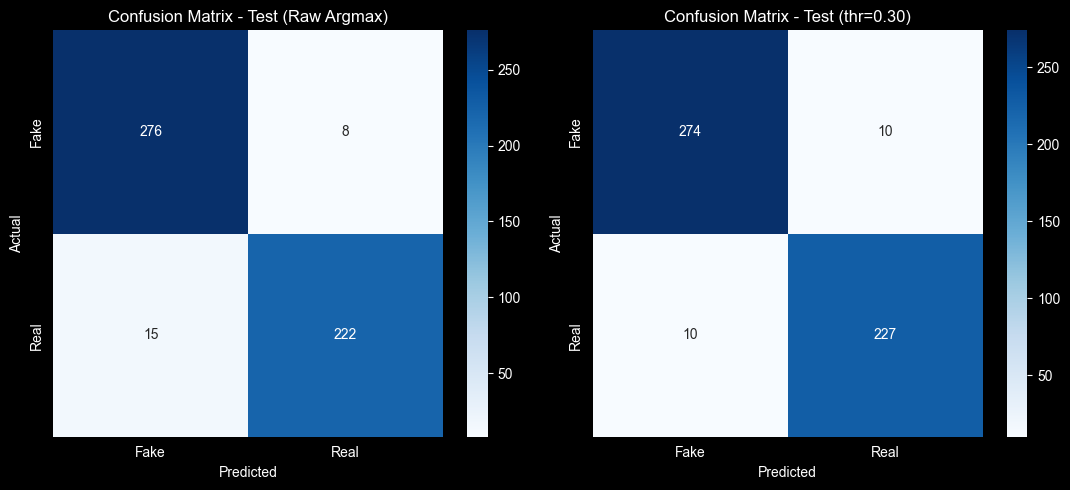

In [16]:
# This cell visualizes the confusion matrix of the final test
# results for:
# - raw argmax predictions
# - validation-selected threshold predictions (if available)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2 if "preds_forced" in test_results else 1, figsize=(11, 5))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

cm_raw = confusion_matrix(test_results["labels"], test_results["preds"])
sns.heatmap(
    cm_raw,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
    ax=axes[0]
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix - Test (Raw Argmax)")

if "preds_forced" in test_results:
    cm_forced = confusion_matrix(test_results["labels"], test_results["preds_forced"])
    sns.heatmap(
        cm_forced,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Fake", "Real"],
        yticklabels=["Fake", "Real"],
        ax=axes[1]
    )
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title(f"Confusion Matrix - Test (thr={test_results['forced_threshold']:.2f})")

plt.tight_layout()
plt.show()